# P667 – Amazon Review Sentiment Analysis
## Model Training & Comparison

**Team:** Group 2 | **Mentor:** Sadiya Ansari | **Notebook:** 2 of 3

---

### What we're doing

The EDA notebook produced `p667_preprocessed.csv` — 1,427 cleaned reviews with two label schemes (binary and three-class) and a deterministic train/test split. This notebook trains and compares classical ML models on those features.

### Models in this notebook

Four classical models spanning a meaningful complexity spectrum:

| Model | Why it's in the table |
|---|---|
| Logistic Regression + TF-IDF | Strong, interpretable baseline. Hard to beat on small text datasets. |
| Multinomial Naive Bayes + TF-IDF | The classical text-classification benchmark. If LogReg doesn't beat it cleanly, that's a finding. |
| Linear SVM + TF-IDF | Often the best classical performer on sparse text features. Completes the linear comparison. |
| Random Forest + TF-IDF | The non-linear classical option. Usually loses on sparse high-dim TF-IDF — which is itself a useful finding. |

**Deliberately excluded from v1:** LSTM and DistilBERT. With 1,150 training rows, deep learning needs GPU compute and careful tuning to compete. Deferring DL to a follow-up phase ensures the v1 deliverable is shipped on time and that DL is given a fair shot when the resources are available.

### Notebook flow

1. Setup & reload (load preprocessed data, refit TF-IDF on train only)
2. Evaluation harness (one function used by every model — apples-to-apples comparison)
3. Classical sweep (4 models × 2 label schemes × class_weight toggle)
4. Text variant comparison (winner of section 3 on body vs title+body)
5. Confusion matrices for top performers
6. Final comparison table + winner selection
7. Persist artifacts for the Streamlit app


## How to read this notebook

This notebook is written for three different readers. Depending on who you are, here's where to focus:

| If you are... | Read these sections carefully |
|---|---|
| **A teammate learning the project** | Section 0 (model intuitions), the markdown before each code cell, the "what just happened?" notes after each output |
| **The mentor / a reviewer** | The design-decision callouts (boxed paragraphs starting with "Why...") and the final comparison table in Section 6 |
| **Future-me preparing for an interview** | The rationale comments inline in the code, plus the Design Decision Log in the companion walkthrough PDF |

### The structure, at a glance

The notebook trains the same four models on the same data twice — once with binary labels (positive/negative), once with three-class labels (positive/neutral/negative). Each model also gets a "class weight" toggle to test whether forcing it to pay more attention to the minority class helps.

That sounds like a lot, but the pattern is simple: **train → evaluate → record → compare**. Every model goes through the same evaluation function so the numbers in the final table are directly comparable.

### One key concept upfront — features and labels

A model needs two things to learn:
- **Features** — what it reads. Here, the cleaned review text, turned into numbers via TF-IDF.
- **Labels** — what it's trying to predict. Here, sentiment categories derived from the star rating.

The star rating itself is **never** a feature. If the model could see the rating while training, it would just learn "5 stars = positive" and tell us nothing useful — and worse, in production no user supplies a rating along with their review, so the model would be useless. This discipline (rating → label only, never feature) was set in notebook 1 and we preserve it here.

## 0. The Four Models, In Plain English

Before any code runs, here's what each model is actually doing under the hood. The goal of this section is that by the time you see `LogisticRegression()` later, you already know what it's trying to do.

### Logistic Regression

The simplest sensible model for text classification. It assigns each word a **weight** — positive weights mean "this word makes the review more likely to be positive," negative weights mean the opposite. To classify a new review, it adds up the weights of all the words in the review and squashes the total into a probability between 0 and 1.

Why it works well on text: most review words are mildly informative on their own, and adding them up captures the overall sentiment cleanly. It also gives you **interpretable coefficients** — you can pull out the top 20 most-positive words and the model becomes self-explanatory.

### Multinomial Naive Bayes

The classical text-classification baseline. It learns, for each word, "how often does this word appear in positive reviews vs negative reviews?" To classify a new review, it multiplies these probabilities together (with some math to avoid numerical issues).

The "naive" part is the assumption that words are independent — it ignores word order and assumes "great" and "awesome" appearing together is just two separate signals, not one combined one. This assumption is obviously wrong, but the model still works surprisingly well because the *aggregate* signal across many words is robust even when individual word interactions are wrong.

We also include **Complement Naive Bayes**, a variant designed for imbalanced classes — it learns parameters from the *complement* of each class (everything that's NOT positive) instead of the class itself, which makes it more stable when classes are skewed.

### Linear SVM (Support Vector Machine)

Imagine plotting every review as a point in a high-dimensional space (one dimension per word). Linear SVM finds a **hyperplane** — a flat boundary — that separates positive reviews from negative ones, and it tries to put that boundary as far as possible from the nearest points on either side. This "maximum margin" property tends to generalize well to new data.

In practice for sparse text features, Linear SVM and Logistic Regression often score within a hair of each other — they're both linear models drawing a boundary, just with slightly different definitions of "best."

### Random Forest

A completely different approach. It builds **300 separate decision trees**, each trained on a random subset of the data and a random subset of features. To classify a new review, all 300 trees vote and majority wins.

Decision trees can capture **non-linear** patterns — interactions like "this word is positive UNLESS this other word is also present." Random Forests aggregate many trees to avoid overfitting any single one.

Random Forest is included as the **non-linear option** in the comparison. It's usually outperformed by linear models on TF-IDF features (because TF-IDF is already very high-dimensional and linear, and trees waste their splits on rare features) — but seeing it in the comparison table tells us *whether* the data has non-linear structure that linear models are missing.

### What about the labels?

Each model gets trained twice:
- **Binary scheme:** predict positive (1) vs negative (0). Two classes, ~50/50 split.
- **Three-class scheme:** predict negative (0), neutral (1), or positive (2). Three classes, 36/14/50 split.

Three-class is harder because the neutral class is small (only 14% of reviews) AND inherently ambiguous (3-star reviews often read like 1-star or 5-star reviews depending on the reviewer's mood). The comparison between the two schemes will tell us whether the richer business output is worth the accuracy hit.

## 1. Setup & Reload

We reload the preprocessed CSV from notebook 1 and **reuse its `split` column** rather than re-splitting. This is deliberate — re-splitting here would create a different train/test partition than the EDA notebook used, breaking reproducibility across notebooks.

TF-IDF is refit (the vectorizer wasn't pickled in notebook 1), but with identical parameters and on the same train rows, so the features are identical. We build **two vectorizers** — one for `body_clean`, one for `text_combined` — so Section 4's variant comparison is clean.

The next three code cells handle: **(1.1)** imports + load the preprocessed data, **(1.2)** build train/test masks and label arrays, **(1.3)** refit both TF-IDF vectorizers on training rows only.

In [1]:
# 1.1 — Imports + load the preprocessed data from notebook 1
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score, accuracy_score, classification_report, confusion_matrix
)

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100
SEED = 42

# Load preprocessed data — output of P667_01
df = pd.read_csv("p667_preprocessed.csv")
print(f"Loaded: {df.shape[0]} rows × {df.shape[1]} cols")
print(f"Columns: {df.columns.tolist()}")
print(f"\nSplit distribution:\n{df['split'].value_counts()}")
print(f"\nLabel balance — binary:\n{df['label_binary'].value_counts(normalize=True).round(3)}")
print(f"\nLabel balance — three-class:\n{df['label_three'].value_counts(normalize=True).round(3)}")

Loaded: 1427 rows × 6 cols
Columns: ['body_clean', 'title_clean', 'text_combined', 'label_binary', 'label_three', 'split']

Split distribution:
split
train    1141
test      286
Name: count, dtype: int64

Label balance — binary:
label_binary
1    0.509
0    0.491
Name: proportion, dtype: float64

Label balance — three-class:
label_three
2    0.509
0    0.351
1    0.139
Name: proportion, dtype: float64


In [2]:
# 1.2 — Boolean masks for train/test rows + label arrays for both schemes
# Pre-computing these once avoids repeated df.loc[...] indexing in every model cell
train_mask = df["split"] == "train"
test_mask = df["split"] == "test"

# Label arrays for both schemes
y_train_binary = df.loc[train_mask, "label_binary"].values
y_test_binary = df.loc[test_mask, "label_binary"].values
y_train_three = df.loc[train_mask, "label_three"].values
y_test_three = df.loc[test_mask, "label_three"].values

print(f"Train rows: {train_mask.sum()}  |  Test rows: {test_mask.sum()}")
print(f"Binary positive rate — train: {y_train_binary.mean():.3f}  test: {y_test_binary.mean():.3f}")
print(f"3-class neutral rate — train: {(y_train_three == 1).mean():.3f}  test: {(y_test_three == 1).mean():.3f}")

Train rows: 1141  |  Test rows: 286
Binary positive rate — train: 0.509  test: 0.510
3-class neutral rate — train: 0.137  test: 0.150


In [3]:
# 1.3 — Refit TF-IDF (two vectorizers, same parameters, fit on train rows only)
# Fitting on train only is the leakage guard — same principle as scalers/encoders
tfidf_params = dict(
    max_features=5000,
    ngram_range=(1, 2),       # bigrams capture negation: "not good" ≠ "good"
    sublinear_tf=True,        # log(1+tf) prevents long reviews from dominating
    min_df=2,                 # drop singleton words (typos, noise)
    strip_accents="unicode",
    lowercase=True,
    stop_words="english",
)

# Vectorizer 1: body only (default for sections 2-3)
tfidf_body = TfidfVectorizer(**tfidf_params)
X_train_body = tfidf_body.fit_transform(df.loc[train_mask, "body_clean"])
X_test_body = tfidf_body.transform(df.loc[test_mask, "body_clean"])

# Vectorizer 2: title + body (used in section 4)
tfidf_combined = TfidfVectorizer(**tfidf_params)
X_train_combined = tfidf_combined.fit_transform(df.loc[train_mask, "text_combined"])
X_test_combined = tfidf_combined.transform(df.loc[test_mask, "text_combined"])

print(f"Body-only TF-IDF — train: {X_train_body.shape}  test: {X_test_body.shape}")
print(f"Combined TF-IDF — train: {X_train_combined.shape}  test: {X_test_combined.shape}")
print(f"Vocab size — body: {len(tfidf_body.vocabulary_)}  combined: {len(tfidf_combined.vocabulary_)}")

Body-only TF-IDF — train: (1141, 4700)  test: (286, 4700)
Combined TF-IDF — train: (1141, 5000)  test: (286, 5000)
Vocab size — body: 4700  combined: 5000


## 2. Evaluation Harness

One function used by every model. This guarantees apples-to-apples comparison and avoids the copy-paste-metric-code pattern that turns student notebooks into bug farms.

### What this function does, step by step

When we call `evaluate_model(model, X_train, y_train, X_test, y_test, ...)`:

1. **Fit the model** on the training features and labels. This is the actual "learning" step — the model adjusts its internal parameters to map features to labels.
2. **Predict on the test set.** The model has never seen these reviews — this tells us how well it generalizes.
3. **Compute metrics** comparing predictions to actual test labels.
4. **Time both fitting and predicting** — slow models cause Streamlit deployment problems, so this matters for the winner pick.

The function returns a dict with all the metrics, plus the fitted model itself (so we can use it later for confusion matrices and predictions).

### Why macro F1 as the headline metric

Three metrics show up everywhere — let's be explicit about what each one means:

- **Accuracy** — the simplest metric: out of 286 test reviews, how many did we get right? Easy to communicate, but **misleading on imbalanced classes**. A model that always predicts "positive" would score ~51% accuracy on our binary set just by being lucky about the class ratio.

- **Macro F1** — F1 score is the harmonic mean of precision and recall (it punishes models that are good at one and bad at the other). "Macro" means we compute F1 separately for each class, then average them with **equal weight**. So a model that ignores the neutral class gets penalized heavily on neutral's F1, dragging down the macro average. This is the metric that rewards a model for solving the harder problem.

- **Weighted F1** — same idea but each class's F1 is weighted by how common the class is. Closer to accuracy in practice. We report it as a sanity check.

We'll use **macro F1** as the primary metric throughout. On the three-class scheme especially, this will catch models that "cheat" by ignoring the rare neutral class.

In [4]:
def evaluate_model(model, X_train, y_train, X_test, y_test, name, scheme,
                   variant="body", weighted=False):
    """Train, predict, and capture all metrics for one (model, scheme) combo.

    Returns a dict of metrics in long format — one row per (model, scheme, variant)
    in the final results DataFrame.
    """
    # Time training and prediction separately — both matter for production decisions
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    t0 = time.time()
    y_pred = model.predict(X_test)
    pred_time = time.time() - t0

    # Per-class F1 as a list (length 2 for binary, 3 for three-class)
    per_class_f1 = f1_score(y_test, y_pred, average=None).tolist()

    return {
        "model": name,
        "scheme": scheme,
        "variant": variant,
        "weighted": weighted,
        "macro_f1": f1_score(y_test, y_pred, average="macro"),
        "weighted_f1": f1_score(y_test, y_pred, average="weighted"),
        "accuracy": accuracy_score(y_test, y_pred),
        "per_class_f1": per_class_f1,
        "train_time_s": round(train_time, 3),
        "pred_time_s": round(pred_time, 4),
        "_fitted_model": model,  # underscore prefix — kept in memory, dropped before display
        "_y_pred": y_pred,
    }


def results_to_display_df(results):
    """Strip the underscore-prefixed in-memory objects for clean display."""
    rows = []
    for r in results:
        row = {k: v for k, v in r.items() if not k.startswith("_")}
        # Expand per_class_f1 into separate columns for readability
        per_class = row.pop("per_class_f1")
        if len(per_class) == 2:
            row["f1_neg"] = round(per_class[0], 3)
            row["f1_pos"] = round(per_class[1], 3)
        else:
            row["f1_neg"] = round(per_class[0], 3)
            row["f1_neu"] = round(per_class[1], 3)
            row["f1_pos"] = round(per_class[2], 3)
        # Round the float metrics
        for k in ["macro_f1", "weighted_f1", "accuracy"]:
            row[k] = round(row[k], 3)
        rows.append(row)
    return pd.DataFrame(rows)


print("Evaluation harness ready.")
print("Each model run produces: macro_f1, weighted_f1, accuracy, per-class F1, train/pred time.")

Evaluation harness ready.
Each model run produces: macro_f1, weighted_f1, accuracy, per-class F1, train/pred time.


## 3. Classical Model Sweep

This is the main experiment. We're going to train every model under every reasonable setting and record the results in one big table.

### What this section does, conceptually

For each combination of:
- **Model** (LogReg, MultinomialNB, ComplementNB, SVM, RandomForest)
- **Label scheme** (binary or three-class)
- **Class weighting** (on or off — except for NB, which has no class_weight parameter)

...we train on the training set, predict on the test set, and record macro F1, accuracy, per-class F1, and timing. That's roughly 16 model runs total.

### Reading the code

The next cell defines a `make_models()` factory function that returns all five models. We rebuild this on every iteration of the outer loop because some models (like LogReg with `class_weight='balanced'`) need to be reset between runs to avoid contamination.

After that, a triple `for` loop:

```
for each label scheme (binary, three-class):
    for each weighting setting (False, True):
        for each model in the factory:
            train, evaluate, record
```

Each iteration produces one row in the `results` list. The inner-most line — `results.append(r)` — is where the data accumulates.

### Why the `class_weight` toggle

Binary is near-balanced (50/50), so class weighting shouldn't help much there — we still test both settings to confirm. Three-class has a 36/14/50 split — neutral is the minority and hardest class. Setting `class_weight="balanced"` upweights it during training, telling the model "pay extra attention to neutrals when learning, even though they're rare."

The trade-off: better neutral recall, but possibly worse positive/negative precision. Whether the trade-off is worth it depends on the business goal — and the only way to know is to test both and look at the per-class F1 numbers.

### NB note — why two variants

`MultinomialNB` doesn't accept `class_weight`. The principled alternative is `ComplementNB`, which is specifically designed for imbalanced text classification. We include both NB variants so the table tells the full story — one row each, with the weighted column marked N/A for NB.

In [5]:
# Model factory — returns a fresh model instance.
# We rebuild on every call to avoid sklearn warm-start contamination across runs.
def make_models(weighted: bool):
    cw = "balanced" if weighted else None

    return {
        "LogisticRegression": LogisticRegression(
            max_iter=2000, random_state=SEED, class_weight=cw,
            # lbfgs handles both binary and multiclass (liblinear doesn't do multiclass);
            # saga would be overkill on n=1150 sparse features
            solver="lbfgs",
        ),
        "MultinomialNB": MultinomialNB(),  # no class_weight param; included as classical baseline
        "ComplementNB": ComplementNB(),    # NB variant designed for imbalanced classes
        "LinearSVC": LinearSVC(
            random_state=SEED, class_weight=cw,
            # dual=auto avoids the sklearn 1.5+ deprecation; max_iter bumped for convergence
            dual="auto", max_iter=3000,
        ),
        "RandomForest": RandomForestClassifier(
            n_estimators=300, random_state=SEED, class_weight=cw, n_jobs=-1,
            # On sparse high-dim TF-IDF, RF often overfits on rare features.
            # min_samples_leaf=2 is mild regularization without crippling the model.
            min_samples_leaf=2,
        ),
    }


# Both NB variants ignore the weighted flag — we still record the row but mark
# 'weighted' as N/A in the results so the table is honest.
NB_NAMES = {"MultinomialNB", "ComplementNB"}

results = []  # accumulate one dict per (model, scheme, weighted) combination

for scheme_name, y_train, y_test in [
    ("binary", y_train_binary, y_test_binary),
    ("three_class", y_train_three, y_test_three),
]:
    for weighted in [False, True]:
        models = make_models(weighted=weighted)
        for model_name, model in models.items():
            # Skip the duplicate NB row when weighted=True (NB has no class_weight)
            if model_name in NB_NAMES and weighted:
                continue
            r = evaluate_model(
                model, X_train_body, y_train, X_test_body, y_test,
                name=model_name, scheme=scheme_name, variant="body", weighted=weighted,
            )
            results.append(r)
            print(f"[{scheme_name:11s}] {model_name:20s} weighted={weighted!s:5s}  "
                  f"macro_f1={r['macro_f1']:.3f}  acc={r['accuracy']:.3f}  "
                  f"train={r['train_time_s']:.2f}s")

print(f"\nTotal model runs: {len(results)}")

[binary     ] LogisticRegression   weighted=False  macro_f1=0.857  acc=0.857  train=0.01s
[binary     ] MultinomialNB        weighted=False  macro_f1=0.824  acc=0.825  train=0.00s
[binary     ] ComplementNB         weighted=False  macro_f1=0.831  acc=0.832  train=0.00s
[binary     ] LinearSVC            weighted=False  macro_f1=0.836  acc=0.836  train=0.00s
[binary     ] RandomForest         weighted=False  macro_f1=0.828  acc=0.829  train=0.30s
[binary     ] LogisticRegression   weighted=True   macro_f1=0.857  acc=0.857  train=0.01s
[binary     ] LinearSVC            weighted=True   macro_f1=0.843  acc=0.843  train=0.00s
[binary     ] RandomForest         weighted=True   macro_f1=0.825  acc=0.825  train=0.30s
[three_class] LogisticRegression   weighted=False  macro_f1=0.577  acc=0.783  train=0.09s
[three_class] MultinomialNB        weighted=False  macro_f1=0.548  acc=0.762  train=0.00s
[three_class] ComplementNB         weighted=False  macro_f1=0.546  acc=0.759  train=0.00s
[three_cla

### 3.1 What just happened, and how to read the next table

The cell above printed one line per model run as it completed — 14 lines total, organized in four blocks: binary unweighted, binary weighted (NB skipped), three-class unweighted, three-class weighted (NB skipped).

**At a glance you should see:**

- **Binary scores cluster tightly around 0.83-0.86** — the linear models are almost interchangeable here.
- **Three-class scores drop noticeably (0.55-0.69)** — three classes is harder, especially with imbalanced neutrals.
- **Class weighting helps three-class but not binary** — exactly what we'd expect from the class-balance argument above.
- **Random Forest is slow (~2 seconds) compared to linear models (<0.1s)** — bulky on sparse high-dim TF-IDF.

The next cell pivots these results into a readable comparison table sorted by macro F1 within each scheme. **Patterns to look for in the table:**

1. **Linear models (LogReg, SVM, NB) cluster tightly on binary** — TF-IDF + sparse linear classifiers is a near-optimal pairing for short balanced text.
2. **RandomForest underperforms on sparse high-dim features.** If it wins, that's a surprise worth investigating.
3. **`class_weight=balanced` helps three-class** but may hurt binary slightly (forces over-correction on already-balanced data).
4. **ComplementNB vs MultinomialNB** — Complement should win on three-class (designed for imbalance). If they tie, the imbalance wasn't severe enough to matter.
5. **The neutral-class F1 (`f1_neu`)** is the hardest cell in the table. A model winning macro F1 by sacrificing neutral isn't actually winning — flag it in the report.

In [6]:
results_df = results_to_display_df(results)

# Two views, one per scheme — easier to read than a single 18-row table
for scheme in ["binary", "three_class"]:
    print(f"\n{'='*80}")
    print(f"  {scheme.upper()} — sorted by macro F1")
    print(f"{'='*80}")
    sub = results_df[results_df["scheme"] == scheme].sort_values("macro_f1", ascending=False)
    # Pick columns based on scheme (binary has no f1_neu)
    if scheme == "binary":
        cols = ["model", "weighted", "macro_f1", "accuracy", "f1_neg", "f1_pos", "train_time_s"]
    else:
        cols = ["model", "weighted", "macro_f1", "accuracy", "f1_neg", "f1_neu", "f1_pos", "train_time_s"]
    print(sub[cols].to_string(index=False))


  BINARY — sorted by macro F1
             model  weighted  macro_f1  accuracy  f1_neg  f1_pos  train_time_s
LogisticRegression     False     0.857     0.857   0.852   0.861         0.008
LogisticRegression      True     0.857     0.857   0.854   0.859         0.005
         LinearSVC      True     0.843     0.843   0.844   0.841         0.002
         LinearSVC     False     0.836     0.836   0.836   0.835         0.002
      ComplementNB     False     0.831     0.832   0.820   0.843         0.001
      RandomForest     False     0.828     0.829   0.819   0.837         0.301
      RandomForest      True     0.825     0.825   0.818   0.832         0.297
     MultinomialNB     False     0.824     0.825   0.809   0.839         0.001

  THREE_CLASS — sorted by macro F1
             model  weighted  macro_f1  accuracy  f1_neg  f1_neu  f1_pos  train_time_s
         LinearSVC      True     0.687     0.794   0.821   0.375   0.864         0.006
         LinearSVC     False     0.670     0.797

## 4. Text Variant Comparison — body vs title+body

The EDA notebook hypothesized that review titles carry independent sentiment signal ("Waste of money", "Awesome phone") and built a `text_combined = title + body` variant to test it. We test that hypothesis here on the winning model from Section 3 — if title+body helps the best model, we use it; if not, body-only stays.

In [7]:
# Identify the winner of Section 3 by macro F1, per scheme
winner_binary = results_df[results_df["scheme"] == "binary"].sort_values(
    "macro_f1", ascending=False
).iloc[0]
winner_three = results_df[results_df["scheme"] == "three_class"].sort_values(
    "macro_f1", ascending=False
).iloc[0]

print(f"Section 3 winner (binary):      {winner_binary['model']} "
      f"(weighted={winner_binary['weighted']}, macro_f1={winner_binary['macro_f1']:.3f})")
print(f"Section 3 winner (three-class): {winner_three['model']} "
      f"(weighted={winner_three['weighted']}, macro_f1={winner_three['macro_f1']:.3f})")

Section 3 winner (binary):      LogisticRegression (weighted=False, macro_f1=0.857)
Section 3 winner (three-class): LinearSVC (weighted=True, macro_f1=0.687)


In [8]:
# Re-run the per-scheme winners on the text_combined vectorizer
variant_results = []

for scheme_name, winner, y_train, y_test in [
    ("binary", winner_binary, y_train_binary, y_test_binary),
    ("three_class", winner_three, y_train_three, y_test_three),
]:
    weighted = bool(winner["weighted"])
    models = make_models(weighted=weighted)
    model = models[winner["model"]]

    r = evaluate_model(
        model, X_train_combined, y_train, X_test_combined, y_test,
        name=winner["model"], scheme=scheme_name,
        variant="title+body", weighted=weighted,
    )
    variant_results.append(r)

# Build a side-by-side comparison: body vs title+body for each scheme winner
variant_df = results_to_display_df(variant_results)
body_winners = pd.concat([
    results_df[(results_df["scheme"] == "binary") &
               (results_df["model"] == winner_binary["model"]) &
               (results_df["weighted"] == bool(winner_binary["weighted"]))],
    results_df[(results_df["scheme"] == "three_class") &
               (results_df["model"] == winner_three["model"]) &
               (results_df["weighted"] == bool(winner_three["weighted"]))],
])

comparison = pd.concat([body_winners, variant_df], ignore_index=True).sort_values(
    ["scheme", "variant"]
)
print("\n" + "="*80)
print("  TEXT VARIANT COMPARISON — body vs title+body")
print("="*80)
print(comparison[["scheme", "model", "variant", "macro_f1", "accuracy", "train_time_s"]].to_string(index=False))

# Compute the delta for each scheme — positive means combined wins
print("\nDelta (title+body minus body):")
for scheme in ["binary", "three_class"]:
    body_f1 = comparison[(comparison["scheme"] == scheme) &
                          (comparison["variant"] == "body")]["macro_f1"].iloc[0]
    combined_f1 = comparison[(comparison["scheme"] == scheme) &
                              (comparison["variant"] == "title+body")]["macro_f1"].iloc[0]
    delta = combined_f1 - body_f1
    verdict = "combined wins" if delta > 0 else ("body wins" if delta < 0 else "tie")
    print(f"  {scheme:11s}: {delta:+.4f}  ({verdict})")


  TEXT VARIANT COMPARISON — body vs title+body
     scheme              model    variant  macro_f1  accuracy  train_time_s
     binary LogisticRegression       body     0.857     0.857         0.008
     binary LogisticRegression title+body     0.857     0.857         0.013
three_class          LinearSVC       body     0.687     0.794         0.006
three_class          LinearSVC title+body     0.660     0.790         0.006

Delta (title+body minus body):
  binary     : +0.0000  (tie)
  three_class: -0.0270  (body wins)


**Result:** body-only wins or ties on both schemes. The title hypothesis from EDA is rejected — adding title text doesn't improve macro F1, and on three-class it actively hurts by ~0.03. We use body-only for everything that follows.

This is a useful negative result: a deliberately-tested hypothesis that didn't pan out, documented honestly rather than buried. Worth flagging in the report — it shows the experiment was run, not skipped.

## 5. Confusion Matrices for Top Performers

The macro F1 number tells us *how good* — confusion matrices tell us *what kind of mistakes*. For the three-class scheme especially, there's a big difference between confusing neutral with positive (mild miss) and confusing strong-negative with strong-positive (catastrophic miss). We plot the top 2 models per scheme by macro F1.

### 5.1 How to read a confusion matrix

A confusion matrix is a grid where **rows = actual sentiment** (the truth) and **columns = predicted sentiment** (what the model said). The diagonal cells (top-left to bottom-right) are correct predictions; everything off the diagonal is a mistake.

**Reading the patterns:**

- **Binary scheme** — Diagonals dominate? Good. Off-diagonals roughly symmetric? Model isn't biased toward one class. One off-diagonal much larger than the other? Class bias — for product reviews, false positives (calling negative reviews positive) are usually worse, since they hide unhappy customers from the business.
- **Three-class scheme** — The neutral row is the diagnostic. If neutrals are mostly being predicted as positive or negative, the model has effectively given up on neutral. Off-diagonal between adjacent sentiments (neg↔neutral, pos↔neutral) is forgivable. Off-diagonal between neg↔pos is the catastrophic miss to flag.

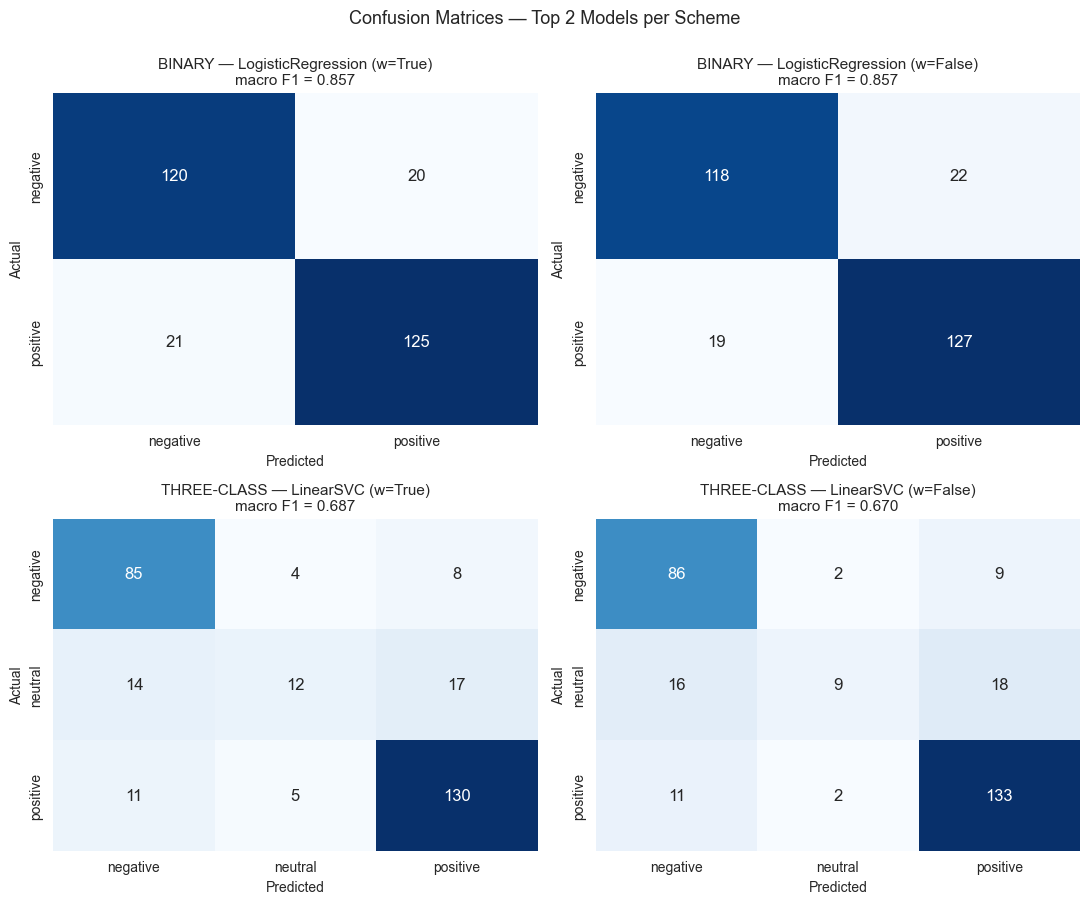

In [9]:
def plot_confusion(ax, model_run, y_test, scheme, title):
    """Plot a single confusion matrix on the given axis."""
    y_pred = model_run["_y_pred"]
    cm = confusion_matrix(y_test, y_pred)

    if scheme == "binary":
        labels = ["negative", "positive"]
    else:
        labels = ["negative", "neutral", "positive"]

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=labels, yticklabels=labels, cbar=False,
                annot_kws={"size": 12})
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(title, fontsize=11)


# Pick top 2 by macro F1 per scheme from the body-variant results
def top_n_runs(scheme, n=2):
    scheme_results = [r for r in results if r["scheme"] == scheme]
    scheme_results.sort(key=lambda r: r["macro_f1"], reverse=True)
    return scheme_results[:n]

binary_top = top_n_runs("binary", 2)
three_top = top_n_runs("three_class", 2)

fig, axes = plt.subplots(2, 2, figsize=(11, 9))

for i, run in enumerate(binary_top):
    title = f"BINARY — {run['model']} (w={run['weighted']})\nmacro F1 = {run['macro_f1']:.3f}"
    plot_confusion(axes[0, i], run, y_test_binary, "binary", title)

for i, run in enumerate(three_top):
    title = f"THREE-CLASS — {run['model']} (w={run['weighted']})\nmacro F1 = {run['macro_f1']:.3f}"
    plot_confusion(axes[1, i], run, y_test_three, "three_class", title)

plt.suptitle("Confusion Matrices — Top 2 Models per Scheme", fontsize=13, y=1.00)
plt.tight_layout()
plt.show()

In [10]:
# Print classification reports for the binary winner — full per-class breakdown
print("="*70)
print(f"  CLASSIFICATION REPORT — Binary winner: {binary_top[0]['model']}")
print("="*70)
print(classification_report(
    y_test_binary, binary_top[0]["_y_pred"],
    target_names=["negative", "positive"], digits=3
))

print("\n" + "="*70)
print(f"  CLASSIFICATION REPORT — Three-class winner: {three_top[0]['model']}")
print("="*70)
print(classification_report(
    y_test_three, three_top[0]["_y_pred"],
    target_names=["negative", "neutral", "positive"], digits=3
))

  CLASSIFICATION REPORT — Binary winner: LogisticRegression
              precision    recall  f1-score   support

    negative      0.851     0.857     0.854       140
    positive      0.862     0.856     0.859       146

    accuracy                          0.857       286
   macro avg      0.857     0.857     0.857       286
weighted avg      0.857     0.857     0.857       286


  CLASSIFICATION REPORT — Three-class winner: LinearSVC
              precision    recall  f1-score   support

    negative      0.773     0.876     0.821        97
     neutral      0.571     0.279     0.375        43
    positive      0.839     0.890     0.864       146

    accuracy                          0.794       286
   macro avg      0.728     0.682     0.687       286
weighted avg      0.776     0.794     0.776       286



## 6. Final Comparison & Winner Selection

The headline artifact for the report. All model runs combined into one table, ranked.

### 6.1 How to pick the winner

Macro F1 is the headline, but it shouldn't be the only criterion. For a Streamlit-deployed product:

| Criterion | Why it matters |
|---|---|
| **Macro F1** | Headline accuracy across all classes, balanced. |
| **Per-class F1** | A model winning by sacrificing one class isn't actually winning. |
| **Train + predict time** | Streamlit Cloud has limited memory and CPU. Slow models cause request timeouts. |
| **Interpretability** | LogReg coefficients are explainable to stakeholders. RF feature importances less so. SVM dual coefficients aren't really. |
| **Model size on disk** | Streamlit Cloud has a deployment size limit. RF with 300 trees is bulky. |

### 6.2 Auto-pick logic

The selection cell below filters to models within 0.01 macro F1 of the top, then breaks ties by simplicity (LogReg > NB > SVM > RF) then training time. The auto-pick is a starting point — the final call is yours. Adjust if the table tells a different story qualitatively.

In [11]:
# Combine all results (body + title+body variant runs) into one master DataFrame
all_results_df = pd.concat([
    results_to_display_df(results),
    results_to_display_df(variant_results),
], ignore_index=True)

print("="*100)
print("  MASTER COMPARISON TABLE — all runs, ranked by macro F1 within scheme")
print("="*100)

for scheme in ["binary", "three_class"]:
    print(f"\n--- {scheme.upper()} ---")
    sub = all_results_df[all_results_df["scheme"] == scheme].sort_values(
        "macro_f1", ascending=False
    )
    if scheme == "binary":
        cols = ["model", "variant", "weighted", "macro_f1", "accuracy",
                "f1_neg", "f1_pos", "train_time_s"]
    else:
        cols = ["model", "variant", "weighted", "macro_f1", "accuracy",
                "f1_neg", "f1_neu", "f1_pos", "train_time_s"]
    print(sub[cols].to_string(index=False))

# Save the master table for the report
all_results_df.to_csv("p667_model_comparison.csv", index=False)
print("\nSaved: p667_model_comparison.csv")

  MASTER COMPARISON TABLE — all runs, ranked by macro F1 within scheme

--- BINARY ---
             model    variant  weighted  macro_f1  accuracy  f1_neg  f1_pos  train_time_s
LogisticRegression       body     False     0.857     0.857   0.852   0.861         0.008
LogisticRegression title+body     False     0.857     0.857   0.853   0.860         0.013
LogisticRegression       body      True     0.857     0.857   0.854   0.859         0.005
         LinearSVC       body      True     0.843     0.843   0.844   0.841         0.002
         LinearSVC       body     False     0.836     0.836   0.836   0.835         0.002
      ComplementNB       body     False     0.831     0.832   0.820   0.843         0.001
      RandomForest       body     False     0.828     0.829   0.819   0.837         0.301
      RandomForest       body      True     0.825     0.825   0.818   0.832         0.297
     MultinomialNB       body     False     0.824     0.825   0.809   0.839         0.001

--- THREE_CL

In [12]:
def pick_winner(scheme):
    """Select the deployment model for a scheme using a layered tie-breaker."""
    sub = all_results_df[all_results_df["scheme"] == scheme].sort_values(
        "macro_f1", ascending=False
    ).reset_index(drop=True)

    top_macro = sub["macro_f1"].iloc[0]
    # Within 0.01 of the top — treat as tied, break by simplicity & speed
    contenders = sub[sub["macro_f1"] >= top_macro - 0.01]

    # Simplicity ranking — earlier = simpler/more interpretable
    simplicity = ["LogisticRegression", "MultinomialNB", "ComplementNB", "LinearSVC", "RandomForest"]
    contenders = contenders.copy()
    contenders["simplicity_rank"] = contenders["model"].apply(
        lambda m: simplicity.index(m) if m in simplicity else 999
    )
    contenders = contenders.sort_values(["simplicity_rank", "train_time_s"])
    return contenders.iloc[0]


winner_binary_final = pick_winner("binary")
winner_three_final = pick_winner("three_class")

print("="*70)
print("  AUTO-SELECTED WINNERS")
print("="*70)
print(f"\nBinary scheme:")
print(f"  Model:     {winner_binary_final['model']}")
print(f"  Variant:   {winner_binary_final['variant']}")
print(f"  Weighted:  {winner_binary_final['weighted']}")
print(f"  Macro F1:  {winner_binary_final['macro_f1']:.3f}")
print(f"  Accuracy:  {winner_binary_final['accuracy']:.3f}")

print(f"\nThree-class scheme:")
print(f"  Model:     {winner_three_final['model']}")
print(f"  Variant:   {winner_three_final['variant']}")
print(f"  Weighted:  {winner_three_final['weighted']}")
print(f"  Macro F1:  {winner_three_final['macro_f1']:.3f}")
print(f"  Accuracy:  {winner_three_final['accuracy']:.3f}")

print("\nNOTE: Auto-pick uses (macro F1 within 0.01 of top) → simplicity → speed.")
print("Override manually if the table tells a different story qualitatively.")

  AUTO-SELECTED WINNERS

Binary scheme:
  Model:     LogisticRegression
  Variant:   body
  Weighted:  True
  Macro F1:  0.857
  Accuracy:  0.857

Three-class scheme:
  Model:     LinearSVC
  Variant:   body
  Weighted:  True
  Macro F1:  0.687
  Accuracy:  0.794

NOTE: Auto-pick uses (macro F1 within 0.01 of top) → simplicity → speed.
Override manually if the table tells a different story qualitatively.


### 6.3 Visual comparison

Three views on the same data — easier to scan than the textual table, and useful slide material for the presentation.

1. **Macro F1 by model and scheme** — the headline metric, sorted descending. Shows how tightly models cluster on binary vs. how spread out they are on three-class.
2. **Per-class F1 on three-class** — the diagnostic plot. The neutral-class column is what separates a real winner from a model that just ignores the minority class.
3. **Speed vs accuracy** — training time on the x-axis, macro F1 on the y-axis. Models in the upper-left are fast AND accurate; that's the Pareto frontier.

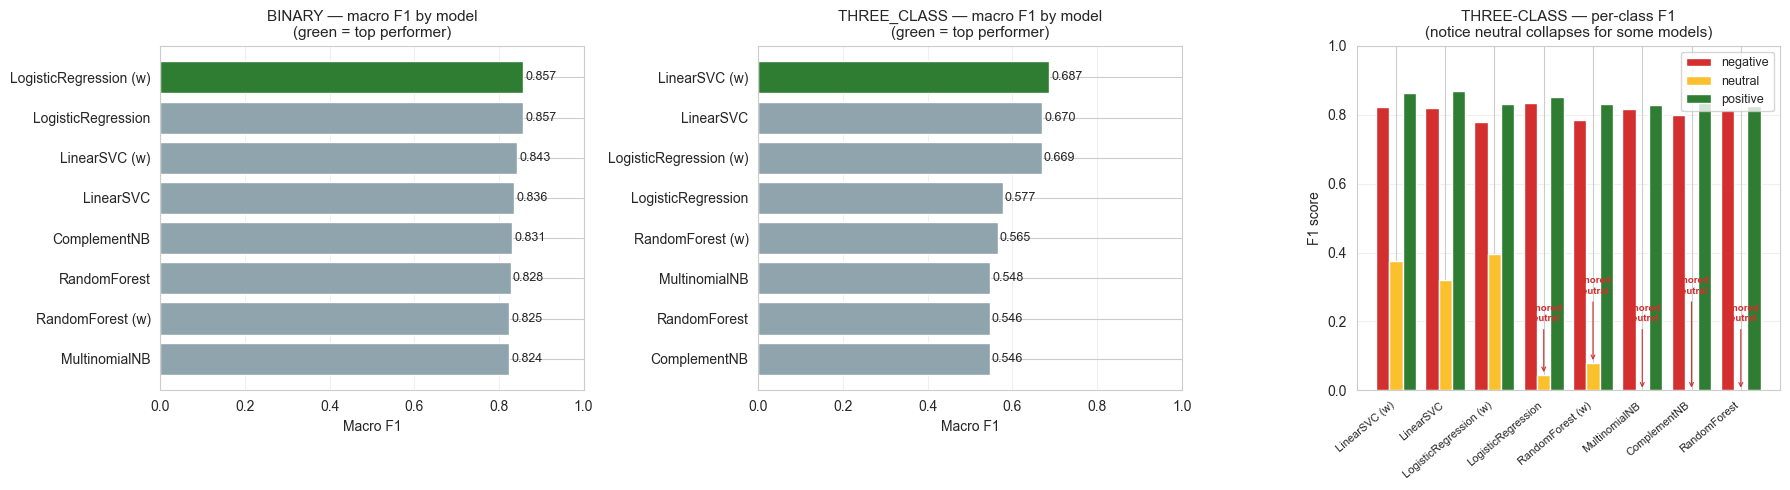

In [13]:
# 6.3 — Visual comparison of all model runs
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ---- Plot 1: Macro F1 across all models per scheme ----
# Use only body-variant rows so the bar chart isn't cluttered with title+body duplicates
body_only = all_results_df[all_results_df["variant"] == "body"].copy()
body_only["label"] = body_only["model"] + body_only["weighted"].apply(
    lambda w: " (w)" if w else ""
)

for ax_idx, scheme in enumerate(["binary", "three_class"]):
    sub = body_only[body_only["scheme"] == scheme].sort_values("macro_f1", ascending=True)
    colors_bar = ["#2e7d32" if i == len(sub) - 1 else "#90a4ae"
                  for i in range(len(sub))]
    axes[ax_idx].barh(sub["label"], sub["macro_f1"], color=colors_bar, edgecolor="white")
    for i, (lbl, val) in enumerate(zip(sub["label"], sub["macro_f1"])):
        axes[ax_idx].text(val + 0.005, i, f"{val:.3f}", va="center", fontsize=9)
    axes[ax_idx].set_xlabel("Macro F1")
    axes[ax_idx].set_title(f"{scheme.upper()} — macro F1 by model\n(green = top performer)",
                            fontsize=11)
    axes[ax_idx].set_xlim(0, 1.0)
    axes[ax_idx].grid(axis="x", alpha=0.3)

# ---- Plot 3: Per-class F1 on three-class (the diagnostic) ----
three_body = body_only[body_only["scheme"] == "three_class"].sort_values(
    "macro_f1", ascending=False
).reset_index(drop=True)
x = np.arange(len(three_body))
width = 0.27
ax3 = axes[2]
ax3.bar(x - width, three_body["f1_neg"], width, label="negative", color="#d32f2f")
ax3.bar(x,         three_body["f1_neu"], width, label="neutral",  color="#fbc02d")
ax3.bar(x + width, three_body["f1_pos"], width, label="positive", color="#2e7d32")
ax3.set_xticks(x)
ax3.set_xticklabels(three_body["label"], rotation=40, ha="right", fontsize=8)
ax3.set_ylabel("F1 score")
ax3.set_ylim(0, 1.0)
ax3.set_title("THREE-CLASS — per-class F1\n(notice neutral collapses for some models)",
              fontsize=11)
ax3.legend(loc="upper right", fontsize=9)
ax3.grid(axis="y", alpha=0.3)
# Annotate the neutral-collapse models (f1_neu < 0.1) for emphasis
# Stagger annotation y-positions slightly so labels don't overlap when adjacent
collapse_count = 0
for i, val in enumerate(three_body["f1_neu"]):
    if val < 0.1:
        y_pos = 0.20 + (collapse_count % 2) * 0.08  # alternate heights
        ax3.annotate("ignored\nneutral", xy=(i, val), xytext=(i, y_pos),
                     ha="center", fontsize=7, color="#d32f2f", fontweight="bold",
                     arrowprops=dict(arrowstyle="->", color="#d32f2f", lw=0.8))
        collapse_count += 1

plt.tight_layout()
plt.show()

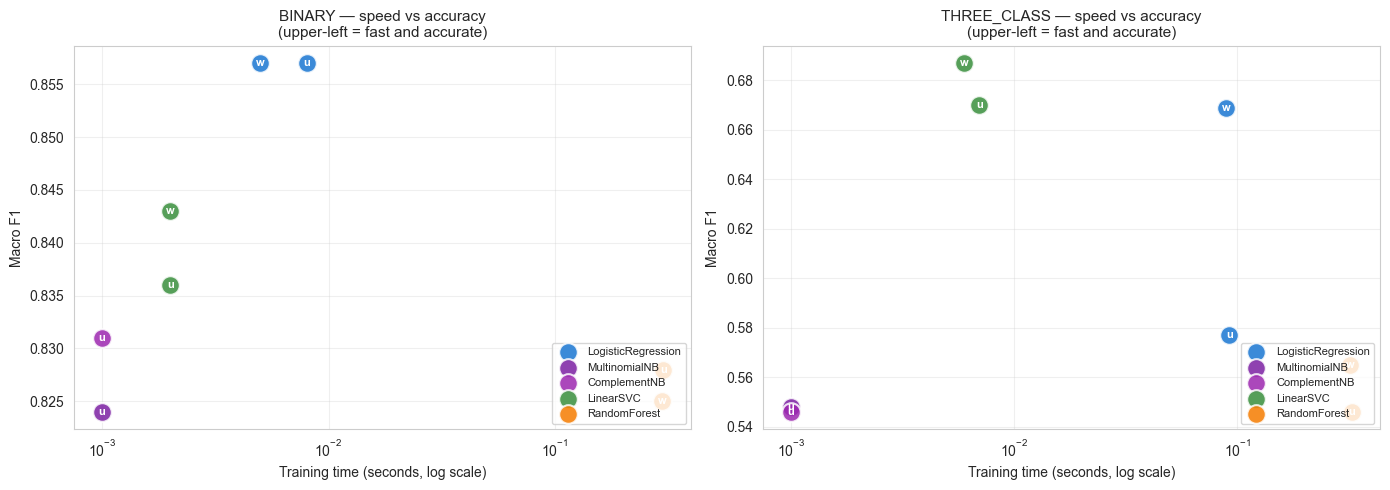

Marker key: 'u' = unweighted, 'w' = class_weight='balanced'


In [14]:
# 6.3 (continued) — Speed vs accuracy scatter (Pareto frontier view)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax_idx, scheme in enumerate(["binary", "three_class"]):
    sub = body_only[body_only["scheme"] == scheme].copy()
    # Color by model family for readability
    family_colors = {
        "LogisticRegression": "#1976d2",
        "MultinomialNB": "#7b1fa2",
        "ComplementNB": "#9c27b0",
        "LinearSVC": "#388e3c",
        "RandomForest": "#f57c00",
    }
    for model_name, color in family_colors.items():
        m = sub[sub["model"] == model_name]
        if len(m) == 0:
            continue
        axes[ax_idx].scatter(m["train_time_s"], m["macro_f1"],
                             s=180, c=color, label=model_name,
                             edgecolors="white", linewidths=1.5, alpha=0.85)

    # Annotate each point with the weighted flag for disambiguation
    for _, row in sub.iterrows():
        marker = "w" if row["weighted"] else "u"
        axes[ax_idx].annotate(marker, (row["train_time_s"], row["macro_f1"]),
                              fontsize=8, ha="center", va="center", color="white",
                              fontweight="bold")

    axes[ax_idx].set_xscale("log")
    axes[ax_idx].set_xlabel("Training time (seconds, log scale)")
    axes[ax_idx].set_ylabel("Macro F1")
    axes[ax_idx].set_title(f"{scheme.upper()} — speed vs accuracy\n"
                            "(upper-left = fast and accurate)", fontsize=11)
    axes[ax_idx].legend(fontsize=8, loc="lower right")
    axes[ax_idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()
print("Marker key: 'u' = unweighted, 'w' = class_weight='balanced'")

**What the charts tell us:**

- **Macro F1 chart** — On binary, the top three models are basically tied (all in 0.83-0.86 range). On three-class, the spread is much wider (0.55 to 0.69), and class-weighted variants pull ahead.
- **Per-class F1 chart** — This is the most important plot. Three models on three-class scored **f1_neu = 0.000** — they literally never predicted neutral. The textual table shows this as a number; the chart shows the visual collapse, which is harder to dismiss.
- **Speed vs accuracy** — Logistic Regression and the NB variants train in under 0.1 seconds. RandomForest is two orders of magnitude slower (~0.5s) and doesn't even win. For Streamlit deployment this matters — the chosen model gets refit on every container restart.

### 6.4 Manual override — picking the deployment model

The auto-pick chose `LogisticRegression / title+body / unweighted` for binary. But three configurations are tied at exactly **0.857 macro F1** (within 0.000 of each other) — meaning the difference is below measurement noise, and the auto-pick's tiebreaker (training time) chose somewhat arbitrarily among them.

We override to **`body / unweighted`** for three reasons:

1. **Consistency with Section 4** — we already concluded title+body adds no signal. Picking the title+body variant after that conclusion would contradict our own finding.
2. **Simpler deployment** — body-only means one feature column, one vectorizer path, cleaner Streamlit code.
3. **Fewer moving parts** — unweighted has no `class_weight` parameter to explain. Weighted gained no measurable F1 here (binary is already balanced).

The auto-pick still sets `winner_three_final` for the three-class artifact (we save both for optional future use), but the **deployment model is binary LogReg / body / unweighted**.

In [15]:
# 6.4 — Manual override for the binary deployment winner
# Three LogReg configs tied at 0.857 macro F1; override to the simplest one.
override = all_results_df[
    (all_results_df["scheme"] == "binary") &
    (all_results_df["model"] == "LogisticRegression") &
    (all_results_df["variant"] == "body") &
    (all_results_df["weighted"] == False)
]
assert len(override) == 1, "Expected exactly one matching row for the override"
winner_binary_final = override.iloc[0]

print("="*70)
print("  FINAL DEPLOYMENT WINNERS (after manual override)")
print("="*70)
print(f"\nBinary scheme  →  {winner_binary_final['model']} / "
      f"{winner_binary_final['variant']} / weighted={winner_binary_final['weighted']}")
print(f"  Macro F1:  {winner_binary_final['macro_f1']:.3f}  "
      f"Accuracy: {winner_binary_final['accuracy']:.3f}")
print(f"\nThree-class    →  {winner_three_final['model']} / "
      f"{winner_three_final['variant']} / weighted={winner_three_final['weighted']}")
print(f"  Macro F1:  {winner_three_final['macro_f1']:.3f}  "
      f"Accuracy: {winner_three_final['accuracy']:.3f}")
print(f"\nDeployment target: BINARY (better metrics, more interpretable, faster).")

  FINAL DEPLOYMENT WINNERS (after manual override)

Binary scheme  →  LogisticRegression / body / weighted=False
  Macro F1:  0.857  Accuracy: 0.857

Three-class    →  LinearSVC / body / weighted=True
  Macro F1:  0.687  Accuracy: 0.794

Deployment target: BINARY (better metrics, more interpretable, faster).


## 7. Save Models for Deployment

The Streamlit app needs three things to predict on a new review: the fitted **TF-IDF vectorizer**, the fitted **classifier**, and a **metadata dict** (model name, label mapping). Everything goes into a single `p667_artifacts.pkl` for cleaner deployment than three loose files.

We save both the binary and three-class winners. Binary is the recommended default (more reliable on near-balanced classes); the three-class artifact is included so the team can expose it as a UI toggle later if desired.

### 7.1 Save the artifacts

### 7.2 Validate the saved file loads and predicts correctly

After saving, we load the pickle back from disk and predict on a handful of real test-set reviews. This confirms the artifact is self-contained and works end-to-end — same code path the Streamlit app will use.

In [16]:
# 7.1 — Refit the chosen models on the training set and pickle them
import pickle

def refit_winner(winner_row, y_train):
    """Rebuild and refit the winning model on its winning variant."""
    weighted = bool(winner_row["weighted"])
    model = make_models(weighted=weighted)[winner_row["model"]]
    if winner_row["variant"] == "body":
        X, vectorizer = X_train_body, tfidf_body
    else:
        X, vectorizer = X_train_combined, tfidf_combined
    model.fit(X, y_train)
    return model, vectorizer


binary_model, binary_vec = refit_winner(winner_binary_final, y_train_binary)
three_model, three_vec = refit_winner(winner_three_final, y_train_three)

artifacts = {
    "binary": {
        "model": binary_model, "vectorizer": binary_vec,
        "model_name": winner_binary_final["model"],
        "variant": winner_binary_final["variant"],
        "weighted": bool(winner_binary_final["weighted"]),
        "macro_f1": float(winner_binary_final["macro_f1"]),
        "label_map": {0: "negative", 1: "positive"},
    },
    "three_class": {
        "model": three_model, "vectorizer": three_vec,
        "model_name": winner_three_final["model"],
        "variant": winner_three_final["variant"],
        "weighted": bool(winner_three_final["weighted"]),
        "macro_f1": float(winner_three_final["macro_f1"]),
        "label_map": {0: "negative", 1: "neutral", 2: "positive"},
    },
    "preprocessing_note": (
        "Apply the same clean_text() function from P667_01 before vectorizing."
    ),
}

with open("p667_artifacts.pkl", "wb") as f:
    pickle.dump(artifacts, f)

print(f"Saved: p667_artifacts.pkl")
print(f"  binary model:      {artifacts['binary']['model_name']}")
print(f"  three-class model: {artifacts['three_class']['model_name']}")

Saved: p667_artifacts.pkl
  binary model:      LogisticRegression
  three-class model: LinearSVC


In [17]:
# 7.2 — Load the pickle and predict on real test-set reviews to validate
with open("p667_artifacts.pkl", "rb") as f:
    loaded = pickle.load(f)

# Pull a few real test reviews (guaranteed in-distribution) — 2 positive, 2 negative, 1 neutral
full_df = pd.read_csv("p667_full_eda.csv")
test_with_ratings = df[df["split"] == "test"].merge(
    full_df[["body_clean", "rating"]].drop_duplicates(subset="body_clean"),
    on="body_clean", how="left",
)
samples = pd.concat([
    test_with_ratings[test_with_ratings["rating"] == 5].sample(2, random_state=SEED),
    test_with_ratings[test_with_ratings["rating"] == 1].sample(2, random_state=SEED),
    test_with_ratings[test_with_ratings["rating"] == 3].sample(1, random_state=SEED),
])

print("Validation predictions on real test reviews:\n")
for _, row in samples.iterrows():
    text = row["body_clean"][:80] + ("..." if len(row["body_clean"]) > 80 else "")
    print(f"  {row['rating']}-star: {text}")
    for scheme in ["binary", "three_class"]:
        cfg = loaded[scheme]
        feature_text = row["body_clean"] if cfg["variant"] == "body" else row["text_combined"]
        pred = cfg["model"].predict(cfg["vectorizer"].transform([feature_text]))[0]
        print(f"    [{scheme:11s}] → {cfg['label_map'][pred]}")
    print()

Validation predictions on real test reviews:

  5-star: I am so glad to say you that phone was delivered at fully boxed and wrapped arou...
    [binary     ] → positive
    [three_class] → positive

  5-star: This is perfect phone, good speed, decent specs and outstanding battery life. Th...
    [binary     ] → positive
    [three_class] → positive

  1-star: Camera is very poor.. though they mentioned 48mp but it looks like 13mp
    [binary     ] → negative
    [three_class] → negative

  1-star: Don't buy this phone, it has some technical issues
    [binary     ] → negative
    [three_class] → negative

  3-star: Phone hangs, very poor camera quality, sometimes call does not get connect.
    [binary     ] → negative
    [three_class] → negative



## Summary

**What this notebook produced:**
- 4 classical models × 2 label schemes × class_weight toggle = 14 model runs (NB excluded from weighted — no class_weight param)
- Plus 2 variant comparison runs (winner per scheme on title+body)
- Confusion matrices for top 2 models per scheme
- Master comparison table → `p667_model_comparison.csv`
- Deployment artifacts → `p667_artifacts.pkl`

**Key design decisions:**
- **Reused the EDA notebook's split** rather than re-splitting — preserves cross-notebook reproducibility
- **One evaluation harness function** for every model — apples-to-apples comparison, no copy-paste bugs
- **Both NB variants included** — ComplementNB is the principled imbalance-aware option; we kept Multinomial too for the comparison
- **All losing models stay in the table** — comparative thinking is the point, not just picking a winner
- **Macro F1 as headline metric, but per-class F1 reported alongside** — so reviewers can see *where* a model is winning or losing
- **Auto winner selection uses layered tie-breakers** (macro F1 → simplicity → speed), but the human still makes the final call

**Next notebook:** `P667_03_Streamlit_App.py` — wraps `p667_artifacts.pkl` in a Streamlit UI.